# ML Credit Card Fraud Detection System
### Jean Fernandes (JEF237@pitt.edu)



## Dataset Summary

This dataset contains European credit card transactions from September 2013, collected over a two-day period. It includes 284,807 transactions, of which 492 are fraudulent, meaning fraud cases represent only 0.172% of the dataset.

Because the dataset is highly imbalanced, standard accuracy is not a useful evaluation metric. Area Under the Precision-Recall Curve (AUPRC) is recommended instead, as it better reflects performance on the minority fraud class.

Most features are anonymized numerical variables produced through PCA transformation. Features `V1` through `V28` are principal components, while `Time` and `Amount` are the only non-PCA features. `Time` records the seconds elapsed since the first transaction, `Amount` records the transaction value, and `Class` is the target variable, where `1` indicates fraud and `0` indicates a legitimate transaction.


## Business Problem

Credit card fraud creates financial losses for banks, payment processors, merchants, and customers. The goal of this project is to build a machine learning model that can classify transactions as fraudulent or legitimate using anonymized transaction features. Because fraudulent transactions are extremely rare, the model should prioritize detecting fraud cases while keeping false alarms low enough that legitimate cardholders are not unnecessarily blocked or inconvenienced.

## Libraries & load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score
from sklearn.base import clone
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, accuracy_score
)

pd.set_option("display.float_format", "{:,.2f}".format)

pd.set_option("display.max_columns", None)

def show(msg, obj=None):
    print("\n======== " + msg + " ========")
    if obj is not None:
        # Use IPython.display for nicer DataFrame/Series rendering
        if isinstance(obj, (pd.DataFrame, pd.Series)):
            display(obj)
        else:
            print(obj)
    # always leave a blank line under the printed/displayed object
    print()

In [2]:
import sys
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from data.load_data import get_credit_card_csv_path, load_credit_card_data

csv_path = get_credit_card_csv_path()
print("CSV file:", csv_path)

df = load_credit_card_data()

C:\Users\jfernandes\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CSV file: C:\Users\jfernandes\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3\creditcard.csv


## Dataset Overview

In [3]:
show("DataFrame shape", df.shape)


======== DataFrame shape ========
(284807, 31)



In [4]:
print("======== DataFrame Info ========")
df.info()

======== DataFrame Info ========
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  f

In [5]:
show("First 5 rows of the dataset", df.head())


======== First 5 rows of the dataset ========


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,-0.55,-0.62,-0.99,-0.31,1.47,-0.47,0.21,0.03,0.40,0.25,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,1.61,1.07,0.49,-0.14,0.64,0.46,-0.11,-0.18,-0.15,-0.07,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,0.62,0.07,0.72,-0.17,2.35,-2.89,1.11,-0.12,-2.26,0.52,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,-0.23,0.18,0.51,-0.29,-0.63,-1.06,-0.68,1.97,-1.23,-0.21,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,-0.82,0.54,1.35,-1.12,0.18,-0.45,-0.24,-0.04,0.80,0.41,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


In [6]:
show("Stats", df.describe())


======== Stats ========


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,"284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00","284,807.00"
mean,"94,813.86",0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,"47,488.15",1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,1.09,1.02,1.00,1.00,0.96,0.92,0.88,0.85,0.84,0.81,0.77,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,-24.59,-4.80,-18.68,-5.79,-19.21,-4.50,-14.13,-25.16,-9.50,-7.21,-54.50,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,"54,201.50",-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,-0.54,-0.76,-0.41,-0.65,-0.43,-0.58,-0.47,-0.48,-0.50,-0.46,-0.21,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,"84,692.00",0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,-0.09,-0.03,0.14,-0.01,0.05,0.05,0.07,-0.07,-0.00,0.00,-0.06,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,"139,320.50",1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,0.45,0.74,0.62,0.66,0.49,0.65,0.52,0.40,0.50,0.46,0.13,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,"172,792.00",2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,23.75,12.02,7.85,7.13,10.53,8.88,17.32,9.25,5.04,5.59,39.42,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,"25,691.16",1.00


## Feature Engineering & Preprocessing

In [7]:
X = df.drop('Class', axis=1).copy()
y = df['Class'].copy()

In [8]:
print("X shape:", X.shape)  # (284807, 30)
print("y shape:", y.shape)  # (284807,)
print(y.value_counts())

X shape: (284807, 30)
y shape: (284807,)
Class
0    284315
1       492
Name: count, dtype: int64


In [9]:
print("Features:", X.shape[1])

Features: 30


## Split

In [10]:
# Split first to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Scale `Time` and `Amount`

In [11]:
scaler = RobustScaler()
cols_to_scale = ["Time", "Amount"]

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [12]:
print(f"Training set size: {X_train_scaled.shape}")
print(f"Test set size: {X_test_scaled.shape}")

print(f"\nTraining set fraud rate: {y_train.mean():.2%}")
print(f"Test set fraud rate: {y_test.mean():.2%}")

Training set size: (227845, 30)
Test set size: (56962, 30)

Training set fraud rate: 0.17%
Test set fraud rate: 0.17%


In [13]:
print("Scaling completed using RobustScaler")
print("\nScaled data statistics:")
print(X_train_scaled.describe())

Scaling completed using RobustScaler

Scaled data statistics:
            Time         V1         V2         V3         V4         V5  \
count 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00   
mean        0.12       0.00      -0.00      -0.00      -0.00       0.00   
std         0.56       1.96       1.65       1.52       1.42       1.38   
min        -1.00     -56.41     -72.72     -48.33      -5.68    -113.74   
25%        -0.36      -0.92      -0.60      -0.89      -0.85      -0.69   
50%         0.00       0.02       0.06       0.18      -0.02      -0.05   
75%         0.64       1.32       0.80       1.03       0.74       0.61   
max         1.03       2.45      22.06       9.38      16.88      34.80   

              V6         V7         V8         V9        V10        V11  \
count 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00 227,845.00   
mean       -0.00       0.00      -0.00       0.00      -0.00      -0.00   
std         1.33       1.24       1.1

## Model Building & Training

In [14]:
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    f1_score,
    fbeta_score,
    roc_auc_score,
)

fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
gb_sample_weight = np.where(y_train == 1, fraud_ratio, 1)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced",
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced",
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        min_samples_split=5,
        random_state=42,
        subsample=0.8,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        scale_pos_weight=fraud_ratio,
        eval_metric="logloss",
        n_jobs=-1,
    ),
}

results = {}

for name, model in models.items():
    print(f"\n{'=' * 60}")
    print(f"Training {name}...")
    print("=" * 60)

    if name == "Gradient Boosting":
        model.fit(X_train_scaled, y_train, sample_weight=gb_sample_weight)
    else:
        model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    auprc = average_precision_score(y_test, y_pred_proba)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results[name] = {
        "model": model,
        "accuracy": accuracy,
        "auprc": auprc,
        "roc_auc": roc_auc,
        "f1": f1,
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"AUPRC:    {auprc:.4f}")
    print(f"ROC-AUC:  {roc_auc:.4f}")
    print(f"F1-Score: {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))


Training Logistic Regression...

Accuracy: 0.9755
AUPRC:    0.7175
ROC-AUC:  0.9720
F1-Score: 0.1142

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962


Training Random Forest...

Accuracy: 0.9994
AUPRC:    0.8453
ROC-AUC:  0.9808
F1-Score: 0.8182

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.81      0.83      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962


Training Gradient Boosting...

Accuracy: 0.9991
AUPRC:    0.8097
ROC-AUC:  0.9521
F1-Score: 0.7619


In [15]:
print("\n" + "=" * 60)
print("ENSEMBLE MODEL - VOTING CLASSIFIER")
print("=" * 60)

voting_clf = VotingClassifier(
    estimators=[
        (
            "lr",
            LogisticRegression(
                max_iter=5000,
                random_state=42,
                class_weight="balanced",
            ),
        ),
        (
            "rf",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced",
            ),
        ),
        (
            "xgb",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.1,
                random_state=42,
                scale_pos_weight=fraud_ratio,
                eval_metric="logloss",
                n_jobs=-1,
            ),
        ),
    ],
    voting="soft",
)

voting_clf.fit(X_train_scaled, y_train)

y_pred_ensemble = voting_clf.predict(X_test_scaled)
y_pred_proba_ensemble = voting_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
auprc_ensemble = average_precision_score(y_test, y_pred_proba_ensemble)
roc_auc_ensemble = roc_auc_score(y_test, y_pred_proba_ensemble)
f1_ensemble = f1_score(y_test, y_pred_ensemble, zero_division=0)

results["Voting Classifier"] = {
    "model": voting_clf,
    "accuracy": accuracy_ensemble,
    "auprc": auprc_ensemble,
    "roc_auc": roc_auc_ensemble,
    "f1": f1_ensemble,
    "y_pred": y_pred_ensemble,
    "y_pred_proba": y_pred_proba_ensemble,
}

print(f"\nEnsemble Accuracy: {accuracy_ensemble:.4f}")
print(f"Ensemble AUPRC:   {auprc_ensemble:.4f}")
print(f"Ensemble ROC-AUC: {roc_auc_ensemble:.4f}")
print(f"Ensemble F1-Score: {f1_ensemble:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ensemble, zero_division=0))


ENSEMBLE MODEL - VOTING CLASSIFIER

Ensemble Accuracy: 0.9994
Ensemble AUPRC:   0.8658
Ensemble ROC-AUC: 0.9737
Ensemble F1-Score: 0.8235

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.86      0.82        98

    accuracy                           1.00     56962
   macro avg       0.90      0.93      0.91     56962
weighted avg       1.00      1.00      1.00     56962



## Model Comparison & Visualization

In [16]:
from sklearn.metrics import precision_score, recall_score

comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "AUPRC": [
        results[m]["auprc"]
        for m in results
    ],
    "Fraud Precision": [
        precision_score(
            y_test,
            results[m]["y_pred"],
            zero_division=0,
        )
        for m in results
    ],
    "Fraud Recall": [
        recall_score(
            y_test,
            results[m]["y_pred"],
            zero_division=0,
        )
        for m in results
    ],
    "F1-Score": [
        results[m]["f1"]
        for m in results
    ],
})

comparison_df = comparison_df.sort_values(
    "AUPRC",
    ascending=False,
).reset_index(drop=True)

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

display(
    comparison_df.style.format({
        "AUPRC": "{:.4f}",
        "Fraud Precision": "{:.4f}",
        "Fraud Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
    })
)


MODEL COMPARISON


,Model,AUPRC,Fraud Precision,Fraud Recall,F1-Score
0,Voting Classifier,0.8658,0.7925,0.8571,0.8235
1,XGBoost,0.8654,0.8351,0.8265,0.8308
2,Random Forest,0.8453,0.8100,0.8265,0.8182
3,Gradient Boosting,0.8097,0.7143,0.8163,0.7619
4,Logistic Regression,0.7175,0.0609,0.9184,0.1142


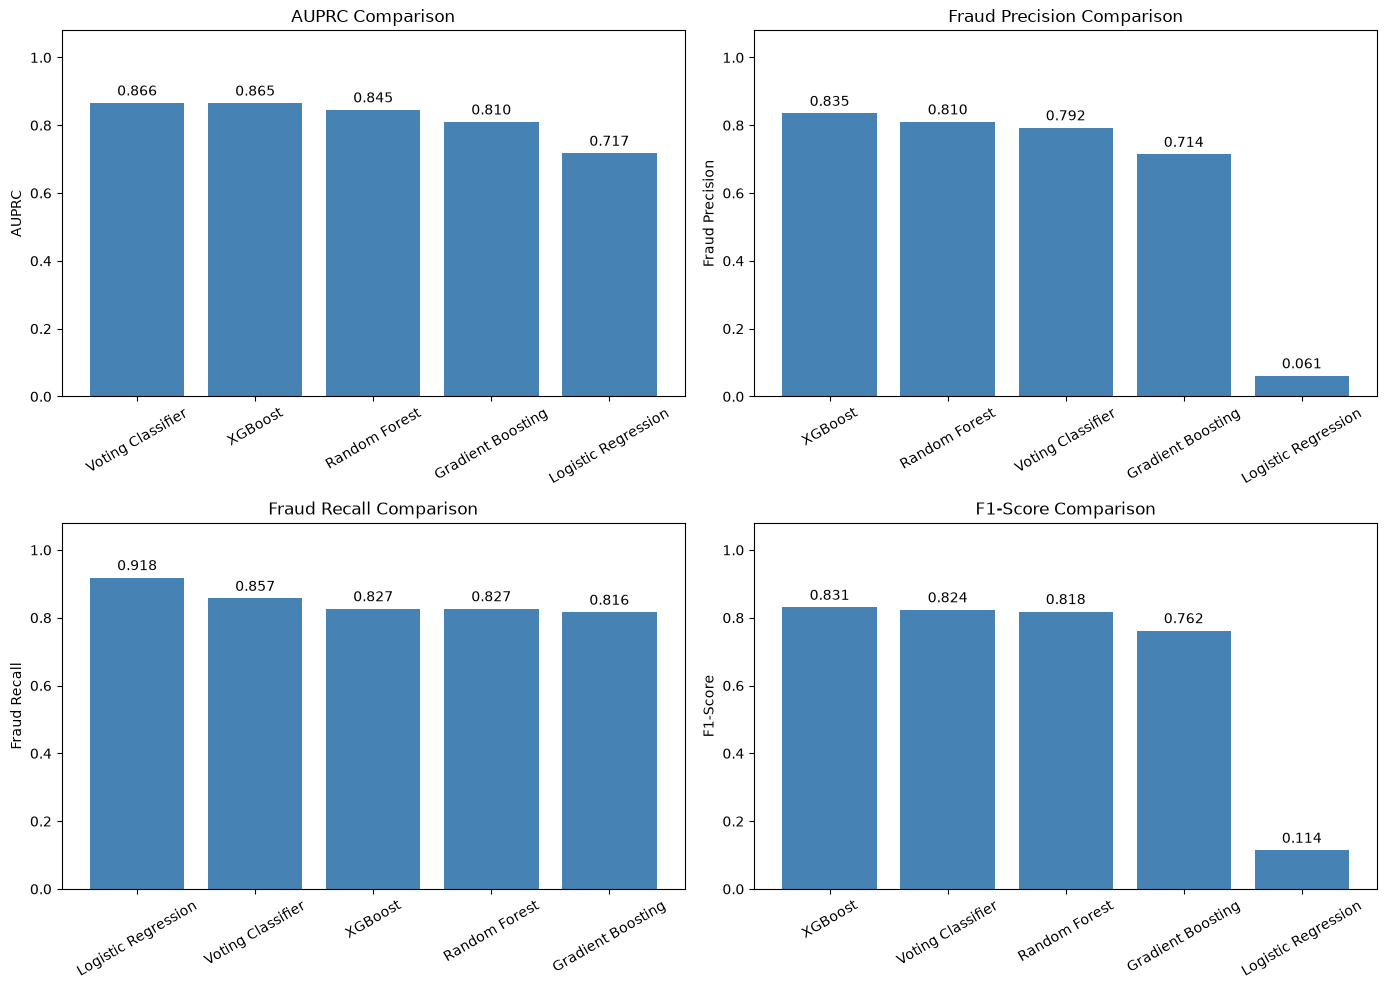

In [17]:
metrics = [
    "AUPRC",
    "Fraud Precision",
    "Fraud Recall",
    "F1-Score",
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sorted_data = comparison_df.sort_values(
        metric,
        ascending=False,
    )

    bars = ax.bar(
        sorted_data["Model"],
        sorted_data[metric],
        color="steelblue",
    )

    ax.set_title(f"{metric} Comparison")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.08)
    ax.tick_params(axis="x", rotation=30)

    ax.bar_label(
        bars,
        labels=[f"{value:.3f}" for value in sorted_data[metric]],
        padding=3,
    )

plt.tight_layout()
plt.show()

## Precision-Recall Curves

Precision-recall curves show the full threshold trade-off for each model. The dashed baseline represents the fraud prevalence in the test set, which is the expected precision of a no-skill classifier.

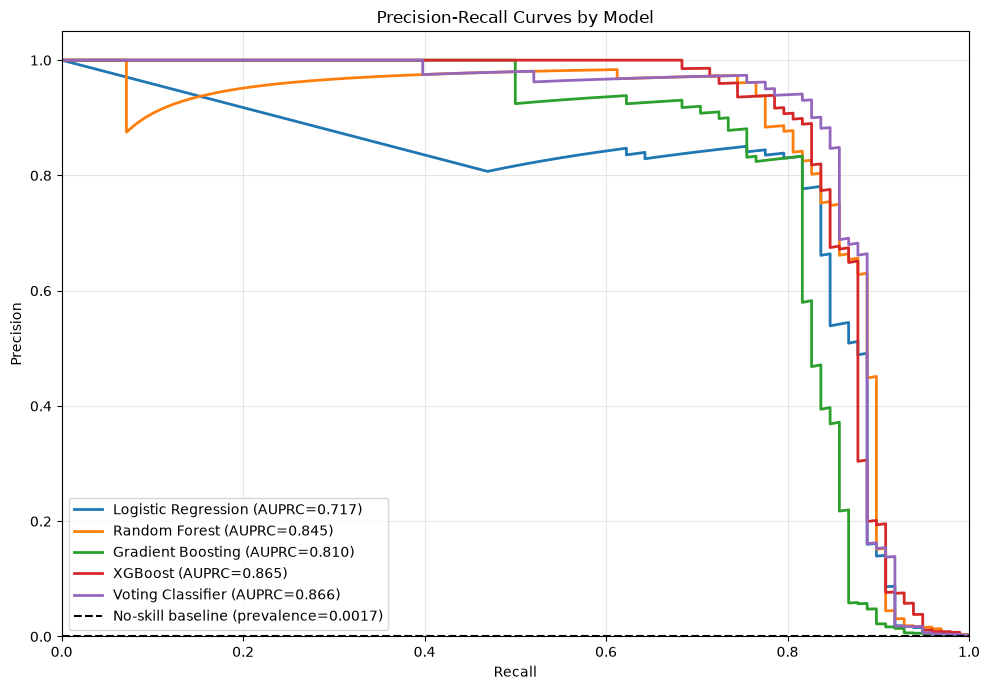

In [18]:
plt.figure(figsize=(10, 7))

prevalence = y_test.mean()

for name, result in results.items():
    precision, recall, _ = precision_recall_curve(
        y_test,
        result["y_pred_proba"],
    )
    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{name} (AUPRC={result['auprc']:.3f})",
    )

plt.axhline(
    prevalence,
    color="black",
    linestyle="--",
    linewidth=1.5,
    label=f"No-skill baseline (prevalence={prevalence:.4f})",
)

plt.title("Precision-Recall Curves by Model")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Confusion matrices

## Financial Cost-Benefit Analysis

This section translates classification errors into estimated business cost. A missed fraud is treated as the transaction amount plus a chargeback fee. A false alarm is treated as a review or customer-friction cost.

In [19]:
chargeback_fee = 25
false_positive_cost = 5

cost_rows = []

for name, result in results.items():
    y_pred_model = result["y_pred"]

    false_negative_mask = (y_test == 1) & (y_pred_model == 0)
    false_positive_mask = (y_test == 0) & (y_pred_model == 1)

    false_negative_cost = X_test.loc[false_negative_mask, "Amount"].sum() + (
        false_negative_mask.sum() * chargeback_fee
    )
    false_positive_total_cost = false_positive_mask.sum() * false_positive_cost

    cost_rows.append({
        "Model": name,
        "False Negatives": int(false_negative_mask.sum()),
        "False Positives": int(false_positive_mask.sum()),
        "FN Cost": false_negative_cost,
        "FP Cost": false_positive_total_cost,
        "Total Error Cost": false_negative_cost + false_positive_total_cost,
    })

cost_benefit_df = (
    pd.DataFrame(cost_rows)
    .sort_values("Total Error Cost")
    .reset_index(drop=True)
)

display(
    cost_benefit_df.style.format({
        "FN Cost": "${:,.2f}",
        "FP Cost": "${:,.2f}",
        "Total Error Cost": "${:,.2f}",
    })
)

,Model,False Negatives,False Positives,FN Cost,FP Cost,Total Error Cost
0,Voting Classifier,14,22,"$2,192.11",$110.00,"$2,302.11"
1,XGBoost,17,16,"$2,547.76",$80.00,"$2,627.76"
2,Gradient Boosting,18,32,"$2,487.22",$160.00,"$2,647.22"
3,Random Forest,17,19,"$2,709.64",$95.00,"$2,804.64"
4,Logistic Regression,8,1388,$858.61,"$6,940.00","$7,798.61"


IndexError: index 4 is out of bounds for axis 0 with size 4

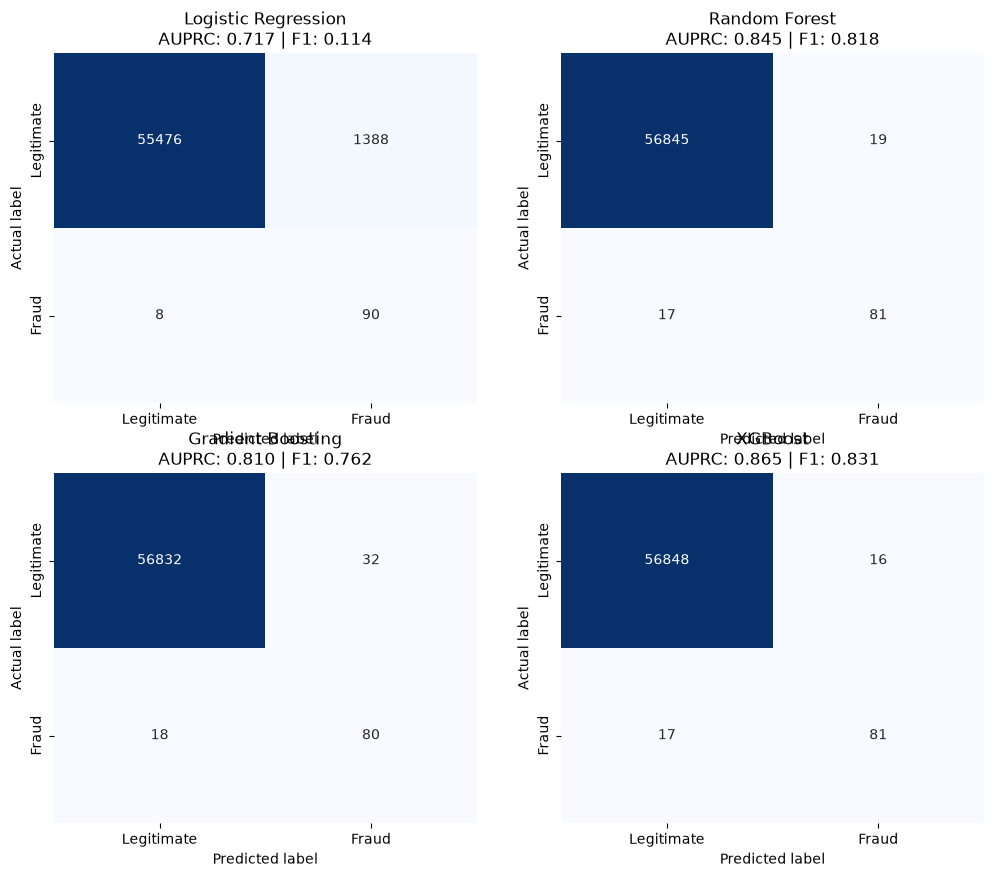

In [20]:
# Confusion matrices
n_models = len(results)
n_cols = 2
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for idx, (name, result) in enumerate(results.items()):
    ax = axes[idx]

    cm = confusion_matrix(y_test, result["y_pred"])

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=["Legitimate", "Fraud"],
        yticklabels=["Legitimate", "Fraud"],
    )

    ax.set_title(
        f"{name}\n"
        f'AUPRC: {result["auprc"]:.3f} | '
        f'F1: {result["f1"]:.3f}'
    )
    ax.set_ylabel("Actual label")
    ax.set_xlabel("Predicted label")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

## Feature Importance Analysis for XGBoost

Feature importance measures how much each input feature contributed to the XGBoost model's decisions. Higher values indicate that a feature provided more useful information when constructing decision trees.

In [21]:
# Retrieve the trained XGBoost model
xgb_model = results["XGBoost"]["model"]

# Extract feature importance
feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train_scaled.columns,
        "Importance": xgb_model.feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

feature_importance_df["Cumulative Importance"] = (
    feature_importance_df["Importance"].cumsum()
)

display(feature_importance_df.head(15))

,Feature,Importance,Cumulative Importance
0,V14,0.47,0.47
1,V4,0.08,0.55
2,V20,0.04,0.59
3,Amount,0.03,0.62
4,V12,0.03,0.65
5,V10,0.03,0.68
6,V7,0.02,0.70
7,V8,0.02,0.72
8,V19,0.02,0.74
9,V13,0.02,0.76


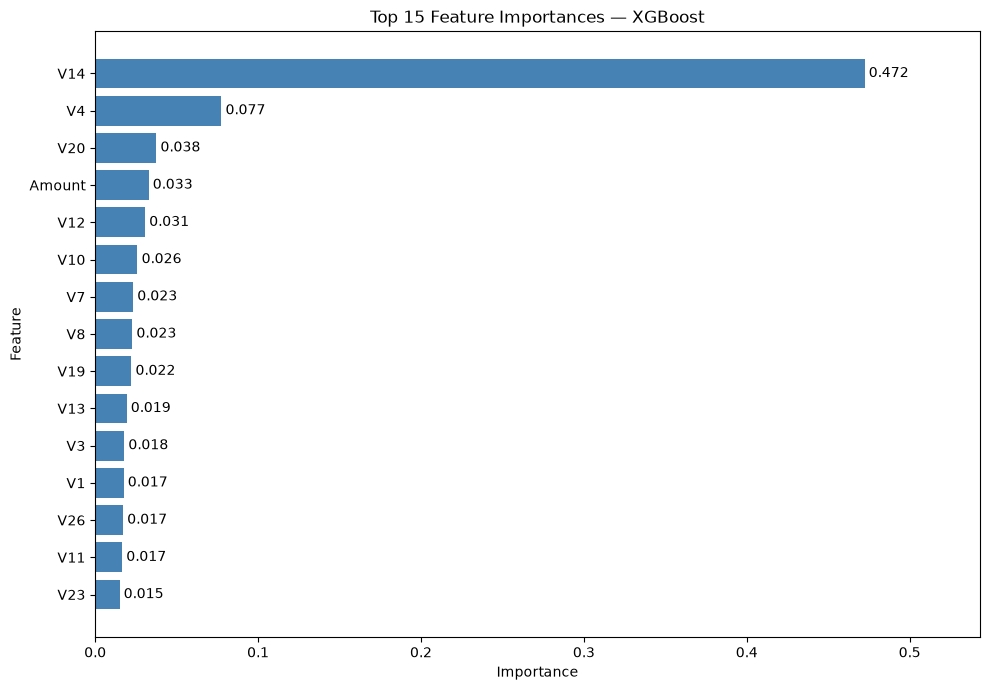

In [22]:
top_n = 15

top_features = (
    feature_importance_df
    .head(top_n)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="steelblue",
)

plt.bar_label(
    bars,
    labels=[
        f"{value:.3f}"
        for value in top_features["Importance"]
    ],
    padding=3,
)

plt.title("Top 15 Feature Importances — XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.xlim(
    0,
    top_features["Importance"].max() * 1.15,
)
plt.tight_layout()
plt.show()

The XGBoost feature-importance analysis shows which variables contributed most strongly to the model's predictions. Because features V1–V28 were anonymized through PCA, their business meaning cannot be interpreted directly. Importance also does not indicate whether higher values increase or decrease fraud risk, and it should not be interpreted as evidence of causation. SHAP analysis would be needed to examine the direction and transaction-level effects of each feature.

## Compact SHAP Summary

SHAP values can show both feature magnitude and direction for individual predictions. Because the dataset uses anonymized PCA features, SHAP still cannot recover business meaning, but it can indicate whether higher or lower values of a component push predictions toward fraud.

In [26]:
!pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp314-cp314-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.49.0-cp314-cp314-win_amd64.whl (43.0 MB)
Using cached numba-0.67.0-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/5 [slicer]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -------- ------------------------------- 1/5 [llvmlite]
   -----


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\jfernandes\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


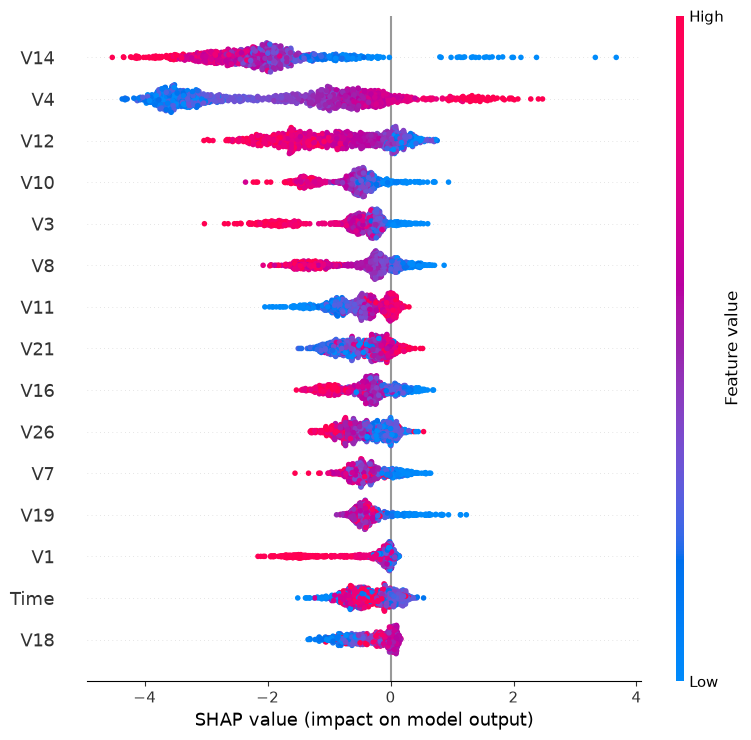

In [27]:
try:
    import shap

    shap_sample = X_test_scaled.sample(
        n=min(1000, len(X_test_scaled)),
        random_state=42,
    )

    explainer = shap.TreeExplainer(results["XGBoost"]["model"])
    shap_values = explainer.shap_values(shap_sample)

    shap.summary_plot(
        shap_values,
        shap_sample,
        max_display=15,
        show=True,
    )
except ImportError:
    print("SHAP is not installed. Install it with `pip install shap` to run this explainability cell.")

## Cross-Validation & Robustness


5-FOLD CROSS-VALIDATION RESULTS

Logistic Regression:
  Mean AUPRC: 0.7469 (+/- 0.0515)
  Fold scores: ['0.7957', '0.7396', '0.6680', '0.8097', '0.7213']

Random Forest:
  Mean AUPRC: 0.8397 (+/- 0.0213)
  Fold scores: ['0.8425', '0.8173', '0.8217', '0.8774', '0.8394']

Gradient Boosting:
  Mean AUPRC: 0.7870 (+/- 0.0298)
  Fold scores: ['0.8198', '0.7348', '0.8117', '0.7872', '0.7815']

XGBoost:
  Mean AUPRC: 0.8483 (+/- 0.0206)
  Fold scores: ['0.8485', '0.8227', '0.8416', '0.8856', '0.8433']


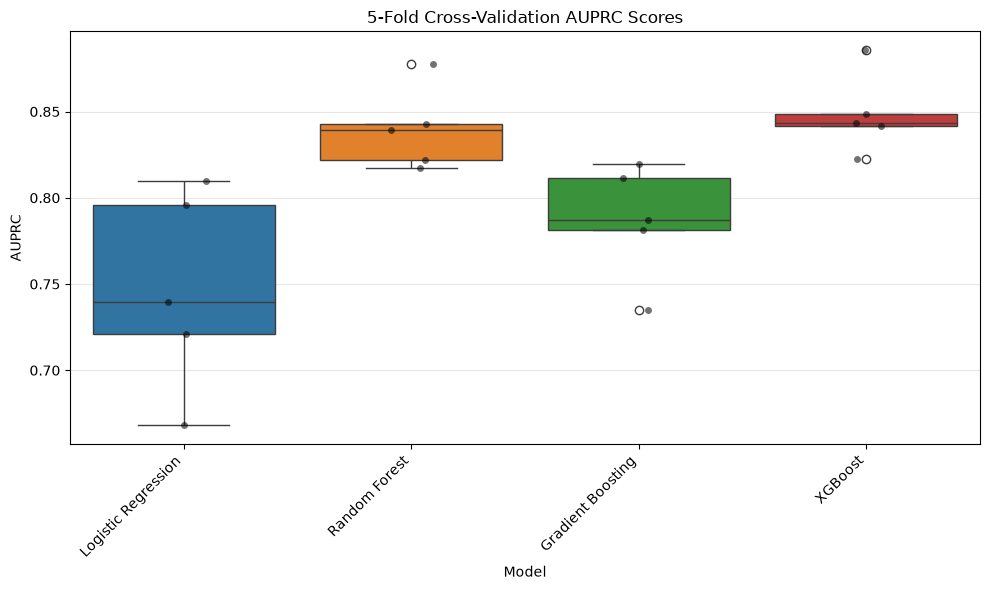

In [28]:
print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name, model in models.items():
    scores = []

    for train_idx, val_idx in kfold.split(X_train_scaled, y_train):
        fold_model = clone(model)
        X_fold_train = X_train_scaled.iloc[train_idx]
        X_fold_val = X_train_scaled.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]

        if name == "XGBoost":
            fold_fraud_ratio = (y_fold_train == 0).sum() / (y_fold_train == 1).sum()
            fold_model.set_params(scale_pos_weight=fold_fraud_ratio)

        if name == "Gradient Boosting":
            fold_fraud_ratio = (y_fold_train == 0).sum() / (y_fold_train == 1).sum()
            fold_sample_weight = np.where(y_fold_train == 1, fold_fraud_ratio, 1)
            fold_model.fit(X_fold_train, y_fold_train, sample_weight=fold_sample_weight)
        else:
            fold_model.fit(X_fold_train, y_fold_train)

        y_fold_proba = fold_model.predict_proba(X_fold_val)[:, 1]
        scores.append(average_precision_score(y_fold_val, y_fold_proba))

    scores = np.array(scores)

    cv_results[name] = scores

    print(f"\n{name}:")
    print(f"  Mean AUPRC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Fold scores: {[f'{score:.4f}' for score in scores]}")

cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 6))
sns.boxplot(data=cv_df)
sns.stripplot(data=cv_df, color="black", alpha=0.55, size=5)
plt.title("5-Fold Cross-Validation AUPRC Scores")
plt.ylabel("AUPRC")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Out-of-Fold Threshold Tuning

The default probability threshold of `0.5` is rarely optimal for fraud detection. The next cell uses out-of-fold training predictions to choose a threshold that maximizes the F2-score, which gives recall more weight than precision.

In [29]:
threshold_model_name = "XGBoost"
threshold_model = models[threshold_model_name]

oof_proba = np.zeros(len(y_train))

for train_idx, val_idx in kfold.split(X_train_scaled, y_train):
    fold_model = clone(threshold_model)
    X_fold_train = X_train_scaled.iloc[train_idx]
    X_fold_val = X_train_scaled.iloc[val_idx]
    y_fold_train = y_train.iloc[train_idx]

    fold_fraud_ratio = (y_fold_train == 0).sum() / (y_fold_train == 1).sum()
    fold_model.set_params(scale_pos_weight=fold_fraud_ratio)
    fold_model.fit(X_fold_train, y_fold_train)
    oof_proba[val_idx] = fold_model.predict_proba(X_fold_val)[:, 1]

threshold_grid = np.linspace(0.01, 0.99, 99)
threshold_scores = []

for threshold in threshold_grid:
    oof_pred = (oof_proba >= threshold).astype(int)
    threshold_scores.append(fbeta_score(y_train, oof_pred, beta=2, zero_division=0))

threshold_tuning_df = pd.DataFrame({
    "Threshold": threshold_grid,
    "OOF F2-Score": threshold_scores,
})

best_threshold_row = threshold_tuning_df.loc[
    threshold_tuning_df["OOF F2-Score"].idxmax()
]
best_threshold = best_threshold_row["Threshold"]

final_model_proba = results[threshold_model_name]["y_pred_proba"]
y_pred_tuned = (final_model_proba >= best_threshold).astype(int)

tuned_precision = precision_score(y_test, y_pred_tuned, zero_division=0)
tuned_recall = recall_score(y_test, y_pred_tuned, zero_division=0)
tuned_f1 = f1_score(y_test, y_pred_tuned, zero_division=0)
tuned_f2 = fbeta_score(y_test, y_pred_tuned, beta=2, zero_division=0)

print(f"Best OOF threshold for {threshold_model_name}: {best_threshold:.2f}")
print(f"Best OOF F2-Score: {best_threshold_row['OOF F2-Score']:.4f}")
print("\nHoldout performance using tuned threshold:")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall:    {tuned_recall:.4f}")
print(f"F1-Score:  {tuned_f1:.4f}")
print(f"F2-Score:  {tuned_f2:.4f}")

display(threshold_tuning_df.sort_values("OOF F2-Score", ascending=False).head(10))


Best OOF threshold for XGBoost: 0.42
Best OOF F2-Score: 0.8436

Holdout performance using tuned threshold:
Precision: 0.8265
Recall:    0.8265
F1-Score:  0.8265
F2-Score:  0.8265


,Threshold,OOF F2-Score
41,0.42,0.84
42,0.43,0.84
39,0.40,0.84
40,0.41,0.84
36,0.37,0.84
37,0.38,0.84
38,0.39,0.84
35,0.36,0.84
49,0.50,0.84
34,0.35,0.84


## Final Model Selection & Summary

The final model is selected using AUPRC as the primary metric because fraudulent transactions are extremely rare in this dataset. AUPRC focuses on how well the model identifies the minority fraud class, making it more informative than accuracy for this problem.

The selected model should balance strong holdout performance with stable cross-validation results. Precision, recall, and F1-score are also reviewed to understand the tradeoff between catching fraudulent transactions and limiting false positives.

In the final table, AUPRC, precision, recall, and F1-score use the default `0.5` classification threshold. The tuned threshold and tuned F2-score are reported separately to show how recall-prioritized threshold optimization changes model behavior.

In [30]:
cv_summary_df = pd.DataFrame({
    "Model": cv_df.columns,
    "CV Mean AUPRC": cv_df.mean().values,
    "CV Std AUPRC": cv_df.std().values,
})

final_summary_df = comparison_df.merge(
    cv_summary_df,
    on="Model",
    how="left",
).sort_values(
    ["AUPRC", "CV Mean AUPRC"],
    ascending=False,
)

final_summary_df["Tuned Threshold"] = np.nan
final_summary_df["Tuned F2-Score"] = np.nan

if "best_threshold" in globals():
    final_summary_df.loc[
        final_summary_df["Model"] == threshold_model_name,
        "Tuned Threshold",
    ] = best_threshold
    final_summary_df.loc[
        final_summary_df["Model"] == threshold_model_name,
        "Tuned F2-Score",
    ] = tuned_f2

final_model_name = final_summary_df.iloc[0]["Model"]
final_model = results[final_model_name]["model"]

print("Final selected model:", final_model_name)
print(
    f"Holdout AUPRC: {final_summary_df.iloc[0]['AUPRC']:.4f} | "
    f"CV Mean AUPRC: {final_summary_df.iloc[0]['CV Mean AUPRC']:.4f}"
)

display(
    final_summary_df.style.format({
        "AUPRC": "{:.4f}",
        "Fraud Precision": "{:.4f}",
        "Fraud Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "CV Mean AUPRC": "{:.4f}",
        "CV Std AUPRC": "{:.4f}",
        "Tuned Threshold": "{:.2f}",
        "Tuned F2-Score": "{:.4f}",
    })
)


Final selected model: Voting Classifier
Holdout AUPRC: 0.8658 | CV Mean AUPRC: nan


,Model,AUPRC,Fraud Precision,Fraud Recall,F1-Score,CV Mean AUPRC,CV Std AUPRC,Tuned Threshold,Tuned F2-Score
0,Voting Classifier,0.8658,0.7925,0.8571,0.8235,nan,nan,nan,nan
1,XGBoost,0.8654,0.8351,0.8265,0.8308,0.8483,0.0230,0.42,0.8265
2,Random Forest,0.8453,0.8100,0.8265,0.8182,0.8397,0.0238,nan,nan
3,Gradient Boosting,0.8097,0.7143,0.8163,0.7619,0.7870,0.0333,nan,nan
4,Logistic Regression,0.7175,0.0609,0.9184,0.1142,0.7469,0.0576,nan,nan


## Export Production Artifacts

The selected model, fitted scaler, and operational threshold are saved so the notebook output can be reused by a future batch-scoring or inference workflow.

In [31]:
from pathlib import Path
import joblib

artifact_dir = Path("../models")
if not artifact_dir.exists():
    artifact_dir = Path("models")
artifact_dir.mkdir(parents=True, exist_ok=True)

operational_threshold = best_threshold if "best_threshold" in globals() else 0.5

joblib.dump(scaler, artifact_dir / "robust_scaler.joblib")
joblib.dump(final_model, artifact_dir / "final_model.joblib")
joblib.dump(
    {
        "model_name": final_model_name,
        "threshold": operational_threshold,
        "primary_metric": "AUPRC",
        "threshold_metric": "F2-score",
    },
    artifact_dir / "model_metadata.joblib",
)

print("Saved artifacts to:", artifact_dir.resolve())
print("Operational threshold:", f"{operational_threshold:.2f}")

Saved artifacts to: C:\Users\jfernandes\OneDrive - Auria Solutions\Desktop\resume-project\models
Operational threshold: 0.42
